# Artificial Neural Network (ANN)
An Artificial Neural Network (ANN) is a machine learning model inspired by the human brain. It is mainly used for:

Classification (Spam detection, sentiment analysis)
Regression (Price prediction)
Image recognition
Natural Language Processing
Pattern recognition
ANN is a core part of Deep Learning and Artificial Intelligence.

# There are 3 Layers in This
Input Layer
Hidden Layer
Output Layer
## Output=Activation((W×X)+B)
# Activation Functions
a mathematical formula applied to a neuron's output in a neural network to introduce nonlinearity, allowing the model to learn complex, non-linear patterns in data
## Common Activation Functions
ReLU → Most used in hidden layers
Sigmoid → Binary classification
Softmax → Multi-class classification

In [2]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv('Iris.csv')

In [4]:
dataset.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
dataset.drop(columns=['Id'])

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
X=dataset.drop(columns=['Species'])
y=dataset['Species']

In [8]:
from sklearn.calibration import LabelEncoder


species=LabelEncoder()
y=species.fit_transform(y)

In [9]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Sequential → A Keras model where layers are stacked one after another in order.

In [11]:
model = Sequential()    

In [12]:
model.add(Input(shape=(4,)))

Dense: A fully connected layer; 16, 8, 3 mean the number of neurons in that layer (last one = number of classes).

In [13]:
# Input + Hidden Layer 1
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))

In [23]:
# Hidden Layer 2
model.add(Dense(units=8, activation='relu'))

In [24]:
# Output Layer
model.add(Dense(units=3, activation='softmax'))

In [25]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
model.summary()

X_train shape: (120, 5)
y_train shape: (120,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910 (3.55 KB)

 Trainable params: 910 (3.55 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Adam Optimizer → An algorithm that adjusts weights automatically using adaptive learning rates to minimize loss.

sparse_categorical_crossentropy → A loss function for multi-class classification when labels are integers (0,1,2).

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910 (3.55 KB)

 Trainable params: 910 (3.55 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

Epoch → One complete pass of the entire training dataset through the model.

In [48]:
print("X_train shape:", X_train.shape)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

X_train shape: (120, 5)
Model input shape: (None, 4)
Model output shape: (None, 3)


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\ROMEO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Model input shape:", model.input_shape)

X_train shape: (120, 5)
y_train shape: (120,)
Model input shape: (None, 4)


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(5,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\ROMEO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 580ms/step - accuracy: 0.3646 - loss: 10.1844 - val_accuracy: 0.2083 - val_loss: 13.2139
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3646 - loss: 8.2114 - val_accuracy: 0.2083 - val_loss: 10.1869
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3646 - loss: 6.0830 - val_accuracy: 0.2083 - val_loss: 7.1877
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3646 - loss: 4.2050 - val_accuracy: 0.2083 - val_loss: 4.1908
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3646 - loss: 2.2797 - val_accuracy: 0.2083 - val_loss: 1.4321
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4792 - loss: 0.6790 - val_accuracy: 0.4167 - val_loss: -0.4917
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5521 - loss: -0.3219 - val_accuracy: 0.3750 - val_loss: -1.7232
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4792 - loss: -0.9000 - val_accuracy: 0.3333 - val_los

In [57]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3000 - loss: -6.2614
Test Accuracy: 0.30000001192092896


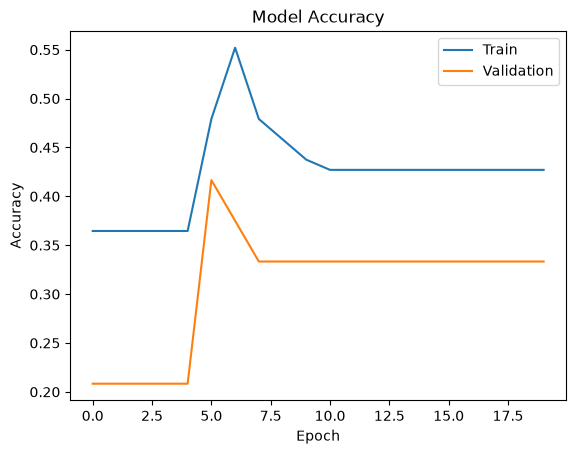

In [60]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

### Take Prediction on One Sample

In [61]:
print(dataset.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [62]:
dataset.columns = dataset.columns.str.strip()

In [64]:
test_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

In [65]:
import numpy as np

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\ROMEO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
import numpy as np

test_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # convert list → numpy

prediction = model.predict(test_sample)

print("Predicted probabilities:", prediction)
predicted_class = prediction.argmax()

print(predicted_class)
predicted_label = species.inverse_transform([predicted_class])

print("Predicted class:", predicted_label[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted probabilities: [[0.3014341  0.58987445 0.10869147]]
1
Predicted class: Iris-versicolor


In [70]:
model.save("ann_model.keras")